# Hate Speech Detection Project
## **CS 4120 | By Mahika Sharma, Aparajitha Karipineni, and Maithili Ubgade**

## Mahika Sharma: Data processing + Random Forest (first iteration)

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import TweetTokenizer
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)

from collections import Counter
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
print('Setup complete.')

Setup complete.


## 1. Load Data

Dataset: Davidson et al. (2017) : *Automated Hate Speech Detection and the Problem of Offensive Language*

**Label key:**
- `0` = hate speech  
- `1` = offensive language  
- `2` = neither

In [6]:
DATA_PATH = 'labeled_data.csv'
df = pd.read_csv(DATA_PATH)
print(f'Loaded {len(df):,} rows, {df.shape[1]} columns')
df.head()

Loaded 24,783 rows, 7 columns


,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [7]:
# Rename for clarity, keeping ALL columns for now
df = df.rename(columns={
    'class': 'label',
    'hate_speech': 'n_hate',
    'offensive_language': 'n_offensive',
    'neither': 'n_neither',
    'count': 'n_annotators'
})
# Drop redundant CSV row-index column if present
df = df.drop(columns=[col for col in df.columns if col.startswith('Unnamed')])

LABEL_NAMES = {0: 'hate_speech', 1: 'offensive', 2: 'neither'}
df['label_name'] = df['label'].map(LABEL_NAMES)

print(df.dtypes)
df.head()

n_annotators     int64
n_hate           int64
n_offensive      int64
n_neither        int64
label            int64
tweet           object
label_name      object
dtype: object


,n_annotators,n_hate,n_offensive,n_neither,label,tweet,label_name
0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...,neither
1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,offensive
2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,offensive
3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,offensive
4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,offensive


## 2. Exploratory Data Analysis

             count   pct
label_name              
offensive    19190  77.4
neither       4163  16.8
hate_speech   1430   5.8


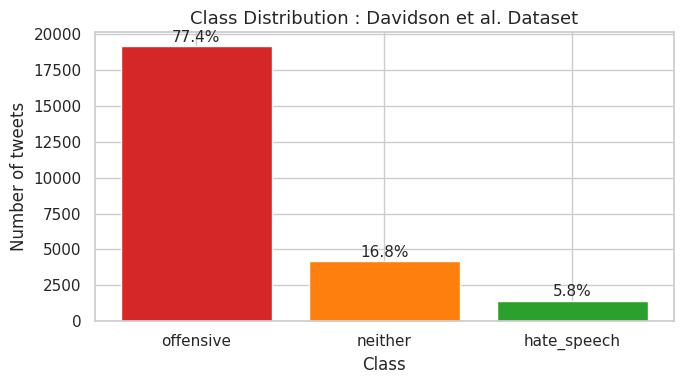

In [8]:
# Class distribution
counts = df['label_name'].value_counts()
pcts   = df['label_name'].value_counts(normalize=True) * 100

dist = pd.DataFrame({'count': counts, 'pct': pcts.round(1)})
print(dist)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(dist.index, dist['count'], color=['#d62728', '#ff7f0e', '#2ca02c'])
for bar, pct in zip(bars, dist['pct']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f'{pct}%', ha='center', va='bottom', fontsize=11
    )
ax.set_title('Class Distribution : Davidson et al. Dataset', fontsize=13)
ax.set_ylabel('Number of tweets')
ax.set_xlabel('Class')
plt.tight_layout()
plt.show()

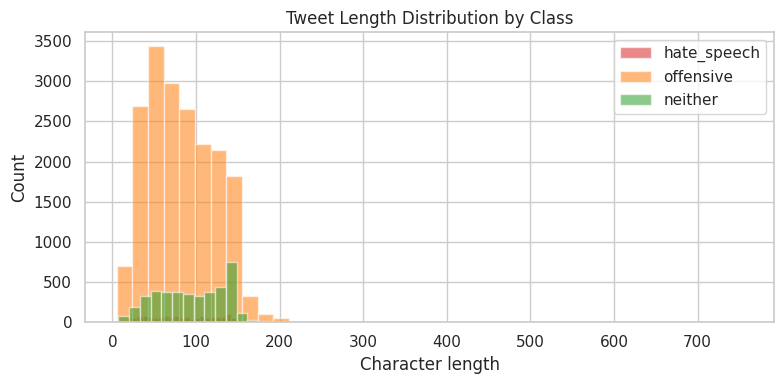

               count  mean   std  min   25%   50%    75%    max
label_name                                                     
hate_speech   1430.0  84.6  40.5  5.0  49.0  82.0  121.0  254.0
neither       4163.0  94.9  41.1  7.0  60.0  97.0  132.0  522.0
offensive    19190.0  83.5  41.5  5.0  50.0  78.0  115.0  754.0


In [9]:
# Tweet length distribution by class
df['tweet_len'] = df['tweet'].str.len()

fig, ax = plt.subplots(figsize=(8, 4))
for label, color in zip(['hate_speech', 'offensive', 'neither'],
                         ['#d62728', '#ff7f0e', '#2ca02c']):
    ax.hist(df[df['label_name'] == label]['tweet_len'],
            bins=40, alpha=0.55, label=label, color=color)
ax.set_title('Tweet Length Distribution by Class')
ax.set_xlabel('Character length')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print(df.groupby('label_name')['tweet_len'].describe().round(1))

In [10]:
# Each tweet was labeled by at least 3 CrowdFlower workers.
# We measure agreement using majority vote share: the fraction
# of annotators who voted for the winning label.
# A score of 1.0 = unanimous; lower scores = contested tweets.

In [11]:
# Majority vote share: votes for the winning label / total annotators
votes_for_label = df.apply(
    lambda row: row[['n_hate', 'n_offensive', 'n_neither']].max(), axis=1
)
df['agreement'] = votes_for_label / df['n_annotators']

print('Agreement score summary:')
print(df['agreement'].describe().round(3))
print(f"\nUnanimous (agreement=1.0):   {(df['agreement'] == 1.0).sum():,} "
      f"({(df['agreement'] == 1.0).mean()*100:.1f}%)")
print(f"Contested (agreement<=0.5):  {(df['agreement'] <= 0.5).sum():,} "
      f"({(df['agreement'] <= 0.5).mean()*100:.1f}%)")

Agreement score summary:
count    24783.000
mean         0.905
std          0.149
min          0.444
25%          0.667
50%          1.000
75%          1.000
max          1.000
Name: agreement, dtype: float64

Unanimous (agreement=1.0):   17,482 (70.5%)
Contested (agreement<=0.5):  60 (0.2%)


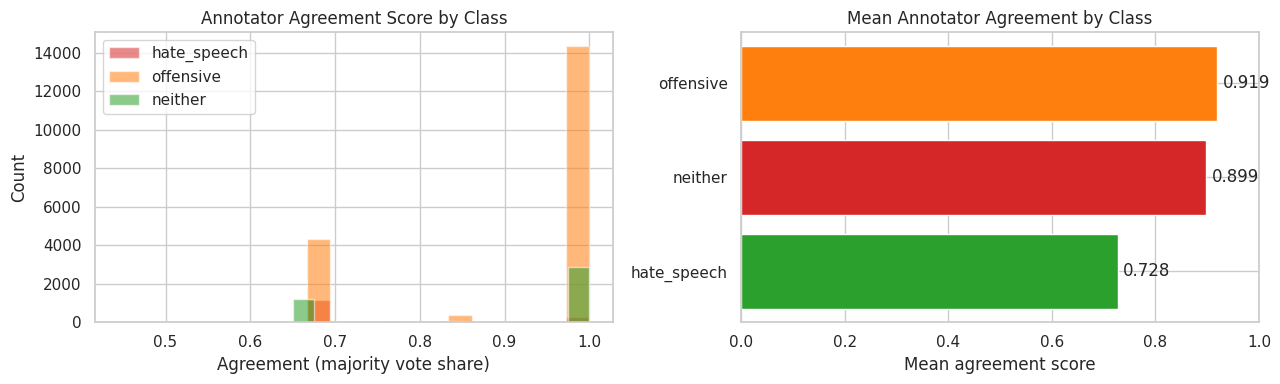

In [12]:
#  Agreement distribution by class
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, color in zip(['hate_speech', 'offensive', 'neither'],
                         ['#d62728', '#ff7f0e', '#2ca02c']):
    axes[0].hist(df[df['label_name'] == label]['agreement'],
                 bins=20, alpha=0.55, label=label, color=color)
axes[0].set_title('Annotator Agreement Score by Class')
axes[0].set_xlabel('Agreement (majority vote share)')
axes[0].set_ylabel('Count')
axes[0].legend()

mean_agreement = df.groupby('label_name')['agreement'].mean().sort_values()
axes[1].barh(mean_agreement.index, mean_agreement.values,
             color=['#2ca02c', '#d62728', '#ff7f0e'])
axes[1].set_title('Mean Annotator Agreement by Class')
axes[1].set_xlabel('Mean agreement score')
axes[1].set_xlim(0, 1)
for i, v in enumerate(mean_agreement.values):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

In [13]:
#  Annotator count distribution
print('Number of annotators per tweet:')
print(df['n_annotators'].value_counts().sort_index())

# Most contested tweets
print('\n MOST CONTESTED TWEETS (lowest agreement) ')
pd.set_option('display.max_colwidth', 100)
print(df.nsmallest(5, 'agreement')[
    ['tweet', 'label_name', 'agreement', 'n_hate', 'n_offensive', 'n_neither']
].to_string(index=False))

Number of annotators per tweet:
n_annotators
3    22807
4      211
6     1571
7       27
9      167
Name: count, dtype: int64

 MOST CONTESTED TWEETS (lowest agreement) 
                                                                                                                                         tweet  label_name  agreement  n_hate  n_offensive  n_neither
HOT ISIS SOCIAL MEDIA PHOTO: Laughing Jihadis Get Baby To Kick Severed Head &#8211; ***warning, graphic*** http://t.co/7Zr8daxNg4 #tcot #pjnet   offensive   0.444444       2            4          3
                                                                                            NBA ALLSTAR weekend is an unofficial negro holiday   offensive   0.444444       3            4          2
      RT @DaTbOySmOkEyy: Shawty said you not gone understand america unless you went to a PWI school, crackers already brainwashed her smh lol hate_speech   0.444444       4            3          2
  "@RTNBA: Drakes new shoes that will 

In [14]:
# Sample tweets per class
for label_id, name in LABEL_NAMES.items():
    print(f'\n=== {name.upper()} (label={label_id}) ===')
    for i, tweet in enumerate(
        df[df['label'] == label_id]['tweet'].sample(3, random_state=42), 1
    ):
        print(f'  {i}. {tweet}')


=== HATE_SPEECH (label=0) ===
  1. @AustinG1135 I do not like talking to you faggot and I did but in a nicely way fag
  2. RT @mitchmancuso: @BrantPrintup:What straight guys take a picture of themselves naked in a hot tun.What fags @jakesiwy @Ryan_Murphy3 @Randy&#8230;
  3. @clinchmtn316 @sixonesixband AMERICA today, the rule of thumb is: when in doubt, blame "whitey"

=== OFFENSIVE (label=1) ===
  1. Why is it everytime I go to cracker barrel the girl with great tits that seats you who is your waitress nope its the chick with 2 teeth
  2. Run that nigga, you don't want that nigga, but I need a bad bitch that's hotter than me
  3. I need a girl from Jamaica I can't fuck with these basic black bitches

=== NEITHER (label=2) ===
  1. RT @chicagotribune: Chicago will not refund $7.7 million made from red light tickets issued after yellow lights were shortened http://t.co/&#8230;
  2. Sometimes, even I gotta tell these hoes to grow up smh
  3. &#8216;Chillin&#8217; With My Homie Or What&#

## 3. Text Preprocessing

Steps applied to each tweet:
1. Lowercase
2. Remove URLs, `RT` tags, hashtag `#` symbol (keep the word)
3. Tokenize with NLTK `TweetTokenizer` (handles Twitter-specific text well)
4. Remove stopwords
5. Keep alphabetic tokens only
6. Lemmatize

In [15]:
tokenizer  = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
lemmatizer = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words('english'))


def preprocess(text: str) -> str:
    """Clean and normalize a tweet; return a single string."""
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'\brt\b', '', text, flags=re.IGNORECASE)
    text = re.sub(r'#(\w+)', r'\1', text)
    tokens = tokenizer.tokenize(text)
    tokens = [
        lemmatizer.lemmatize(tok)
        for tok in tokens
        if tok.isalpha() and tok not in STOP_WORDS
    ]
    return ' '.join(tokens)


df['clean_tweet'] = df['tweet'].apply(preprocess)

# check before/after pairs
pd.set_option('display.max_colwidth', 120)
df[['tweet', 'clean_tweet', 'label_name']].sample(5, random_state=0)

,tweet,clean_tweet,label_name
4129,@Misplaced_Momma \nHello dare momma. I show glad dat u follow me. U lbe screamin hot in dem pitchers. \nYou eva b wi...,hello dare momma show glad dat u follow u lbe screamin hot dem pitcher eva b wit colored men,neither
15081,RT @DymondMarie1: Shoutout to your main bitch !,shoutout main bitch,offensive
16547,RT @MsKeeKee90s: Throw it up! Like a pizza! Get stirring in that pussy like a feature &#128514;&#128514;&#128514; @t...,throw like pizza get stirring pussy like feature,offensive
4273,@Nien_Nunb what did you search? Gay redneck episode 1 play?,search gay redneck episode play,hate_speech
4254,@Ncoleycole u still a mutt tho lol,u still mutt tho lol,neither


In [16]:
# Drop rows where preprocessing produced an empty string
empty_mask = df['clean_tweet'].str.strip() == ''
print(f'Dropping {empty_mask.sum()} empty tweets after preprocessing.')
df = df[~empty_mask].reset_index(drop=True)
print(f'Remaining rows: {len(df):,}')

Dropping 9 empty tweets after preprocessing.
Remaining rows: 24,774


## 4. Train / Test Split

In [17]:
X = df['clean_tweet']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print('\nTrain class distribution:')
print(y_train.value_counts().rename(LABEL_NAMES))
print('\nTest class distribution:')
print(y_test.value_counts().rename(LABEL_NAMES))

Train: 19,819  |  Test: 4,955

Train class distribution:
label
offensive      15349
neither         3326
hate_speech     1144
Name: count, dtype: int64

Test class distribution:
label
offensive      3838
neither         831
hate_speech     286
Name: count, dtype: int64


## 5. TF-IDF Vectorization

Fit only on the training set to avoid data leakage. Using unigrams + bigrams.

In [18]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50_000,
    sublinear_tf=True,
    min_df=3,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'Train matrix: {X_train_tfidf.shape}')
print(f'Test  matrix: {X_test_tfidf.shape}')

Train matrix: (19819, 9921)
Test  matrix: (4955, 9921)


## 6. Random Forest (First Iteration)

`class_weight='balanced'` adjusts weights inversely proportional to class frequency ince hate speech is only ~5.8% of the data

In [19]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train_tfidf, y_train)
print('Training complete.')

Training complete.


## 7. Evaluation

In [20]:
y_pred = rf.predict(X_test_tfidf)
y_pred_prob = rf.predict_proba(X_test_tfidf)

acc= accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr', average='macro')

print(f'Accuracy : {acc:.4f}')
print(f'ROC-AUC  : {roc_auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=list(LABEL_NAMES.values())))

Accuracy : 0.9041
ROC-AUC  : 0.9296

              precision    recall  f1-score   support

 hate_speech       0.48      0.34      0.40       286
   offensive       0.95      0.94      0.94      3838
     neither       0.83      0.94      0.88       831

    accuracy                           0.90      4955
   macro avg       0.75      0.74      0.74      4955
weighted avg       0.90      0.90      0.90      4955



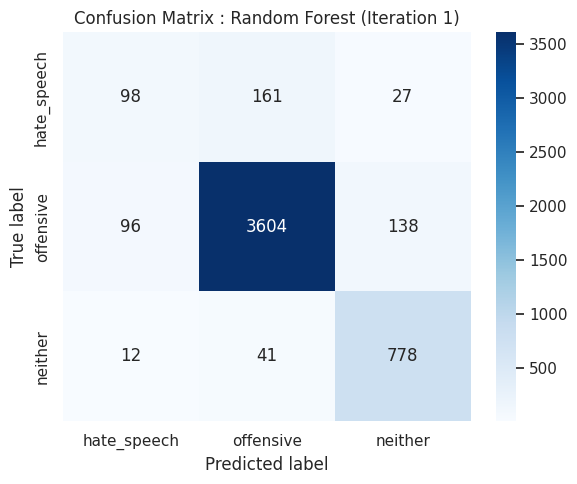

In [21]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
labels = list(LABEL_NAMES.values())

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels, ax=ax
)
ax.set_title('Confusion Matrix : Random Forest (Iteration 1)', fontsize=12)
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
plt.tight_layout()
plt.show()

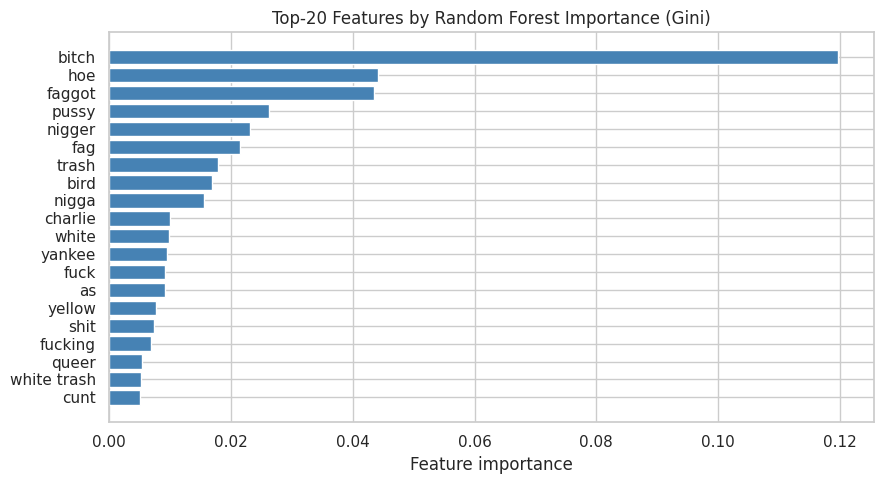

In [22]:
# Top-20 most important features (global Gini importance)
feature_names = np.array(tfidf.get_feature_names_out())
importances   = rf.feature_importances_
top_idx       = np.argsort(importances)[::-1][:20]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(feature_names[top_idx][::-1], importances[top_idx][::-1], color='steelblue')
ax.set_title('Top-20 Features by Random Forest Importance (Gini)', fontsize=12)
ax.set_xlabel('Feature importance')
plt.tight_layout()
plt.show()

## 8. Logistic Regression (First Iteration)

In [23]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1
)

lr.fit(X_train_tfidf, y_train)
print('Logistic Regression training complete.')

Logistic Regression training complete.


## 9. Evaluation

In [24]:
y_pred_lr = lr.predict(X_test_tfidf)
y_pred_prob_lr = lr.predict_proba(X_test_tfidf)

acc_lr = accuracy_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_pred_prob_lr, multi_class='ovr', average='macro')

print(f'Accuracy : {acc_lr:.4f}')
print(f'ROC-AUC  : {roc_auc_lr:.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=list(LABEL_NAMES.values())))

Accuracy : 0.8616
ROC-AUC  : 0.9292

              precision    recall  f1-score   support

 hate_speech       0.33      0.62      0.43       286
   offensive       0.97      0.86      0.91      3838
     neither       0.79      0.94      0.85       831

    accuracy                           0.86      4955
   macro avg       0.69      0.81      0.73      4955
weighted avg       0.90      0.86      0.88      4955



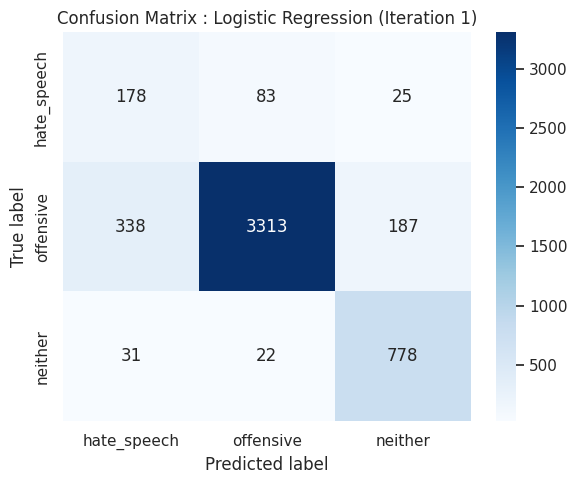

In [25]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm_lr, annot=True, fmt='d', cmap='Blues',
    xticklabels=LABEL_NAMES.values(),
    yticklabels=LABEL_NAMES.values(),
    ax=ax
)
ax.set_title('Confusion Matrix : Logistic Regression (Iteration 1)')
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
plt.tight_layout()
plt.show()

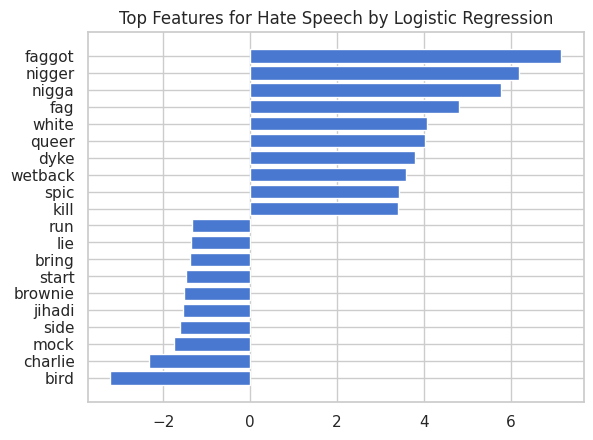

In [26]:
i = 0  # hate_speech

coefs = lr.coef_[i]
top_pos_idx = np.argsort(coefs)[-10:]
top_neg_idx = np.argsort(coefs)[:10]
top_idx = np.concatenate([top_neg_idx, top_pos_idx])

plt.barh(feature_names[top_idx], coefs[top_idx])
plt.title('Top Features for Hate Speech by Logistic Regression')
plt.show()

## 10. LSTM (First Iteration)

In [32]:
vocab = tfidf.vocabulary_.copy()

PAD_IDX = len(vocab)
UNK_IDX = len(vocab) + 1

vocab["<PAD>"] = PAD_IDX
vocab["<UNK>"] = UNK_IDX

VOCAB_SIZE = len(vocab)

print(f"Vocabulary size: {VOCAB_SIZE:,}")

MAX_LEN = 40

def encode(text):
    tokens = text.split()
    seq = [vocab.get(t, UNK_IDX) for t in tokens]

    if len(seq) < MAX_LEN:
        seq += [PAD_IDX] * (MAX_LEN - len(seq))
    else:
        seq = seq[:MAX_LEN]

    return seq


X_train_seq = np.array([encode(t) for t in X_train])
X_test_seq  = np.array([encode(t) for t in X_test])

y_train_arr = y_train.values
y_test_arr  = y_test.values

print("Train sequence shape:", X_train_seq.shape)
print("Test sequence shape:", X_test_seq.shape)

Vocabulary size: 9,923
Train sequence shape: (19819, 40)
Test sequence shape: (4955, 40)


In [33]:
class TweetDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = TweetDataset(X_train_seq, y_train_arr)
test_dataset  = TweetDataset(X_test_seq, y_test_arr)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64)

In [34]:
class LSTMClassifier(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=PAD_IDX
        )

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):

        x = self.embedding(x)

        _, (h, _) = self.lstm(x)

        h = self.dropout(h[-1])

        out = self.fc(h)

        return out

In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lstm = LSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=100,
    hidden_dim=128,
    num_classes=3
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(lstm.parameters(), lr=0.001)

print("LSTM initialized on:", device)

LSTM initialized on: cpu


Train LSTM

In [51]:
EPOCHS = 10
for epoch in range(EPOCHS):

    lstm.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = lstm(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS}  Loss: {total_loss:.4f}")

Epoch 1/10  Loss: 340.4960
Epoch 2/10  Loss: 340.3613
Epoch 3/10  Loss: 340.4813
Epoch 4/10  Loss: 336.8200
Epoch 5/10  Loss: 339.0655
Epoch 6/10  Loss: 337.8942
Epoch 7/10  Loss: 337.3064
Epoch 8/10  Loss: 336.5967
Epoch 9/10  Loss: 339.2702
Epoch 10/10  Loss: 338.8191


## 11. Evaluation

In [52]:
lstm.eval()

y_pred_lstm = []
y_pred_prob_lstm = []

with torch.no_grad():

    for X_batch, _ in test_loader:

        X_batch = X_batch.to(device)

        outputs = lstm(X_batch)

        probs = F.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)

        y_pred_lstm.extend(preds.cpu().numpy())
        y_pred_prob_lstm.extend(probs.cpu().numpy())

In [57]:
acc_lstm = accuracy_score(y_test, y_pred_lstm)

roc_auc_lstm = roc_auc_score(
    y_test,
    y_pred_prob_lstm,
    multi_class='ovr',
    average='macro'
)

print(f'Accuracy : {acc_lstm:.4f}')
print(f'ROC-AUC  : {roc_auc_lstm:.4f}')
print()

print(classification_report(
    y_test,
    y_pred_lstm,
    target_names=list(LABEL_NAMES.values())
))

Accuracy : 0.7776
ROC-AUC  : 0.5116

              precision    recall  f1-score   support

 hate_speech       0.00      0.00      0.00       286
   offensive       0.78      1.00      0.87      3838
     neither       0.89      0.02      0.04       831

    accuracy                           0.78      4955
   macro avg       0.56      0.34      0.30      4955
weighted avg       0.75      0.78      0.68      4955



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


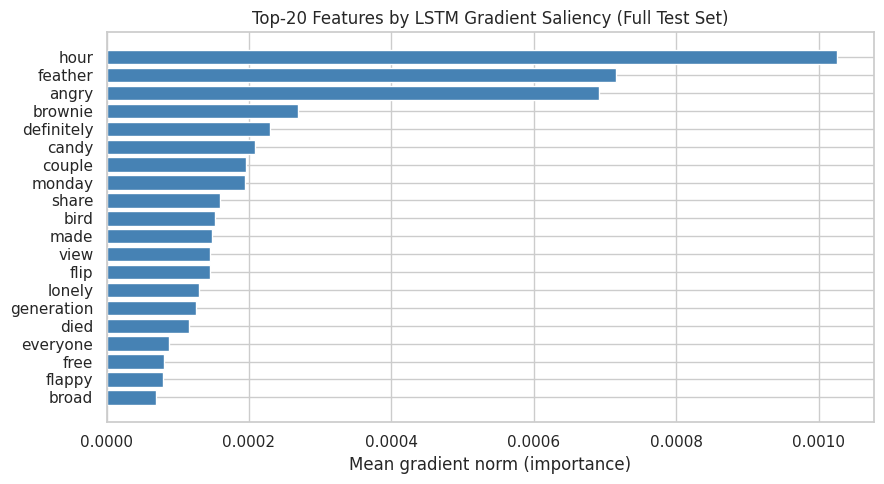

In [74]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

def get_token_importance_scores(model, vocab, device, top_n=20):

  model.eval()

  idx_to_token = {v: k for k, v in vocab.items()}

  token_grad_accum = defaultdict(list)

  for X_batch, _ in test_loader:
    X_batch = X_batch.to(device)

    for i in range(len(X_batch)):
      seq = X_batch[i].unsqueeze(0)

      embeddings = model.embedding(seq)
      embeddings.retain_grad()

      _, (h, _) = model.lstm(embeddings)
      h = model.dropout(h[-1])
      out = model.fc(h)

      pred_class = out.argmax(dim=1)
      model.zero_grad()
      out[0, pred_class].backward()

      grads = embeddings.grad.squeeze(0)
      token_ids = seq.squeeze(0).cpu().numpy()

      for tok_id, grad in zip(token_ids, grads):
        if tok_id in (vocab["<PAD>"], vocab["<UNK>"]):
          continue
        token = idx_to_token.get(tok_id)
        if token:
          token_grad_accum[token].append(grad.norm().item())

  token_importance = {
    tok: np.mean(scores)
    for tok, scores in token_grad_accum.items()
    if len(scores) >= 5
  }

  sorted_tokens = sorted(token_importance.items(), key=lambda x: x[1], reverse=True)[:top_n]
  tokens, scores = zip(*sorted_tokens)
  return list(tokens), list(scores)


tokens, scores = get_token_importance_scores(lstm, vocab, device, top_n=20)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(tokens[::-1], scores[::-1], color='steelblue')
ax.set_title('Top-20 Features by LSTM Gradient Saliency (Full Test Set)', fontsize=12)
ax.set_xlabel('Mean gradient norm (importance)')
plt.tight_layout()
plt.show()

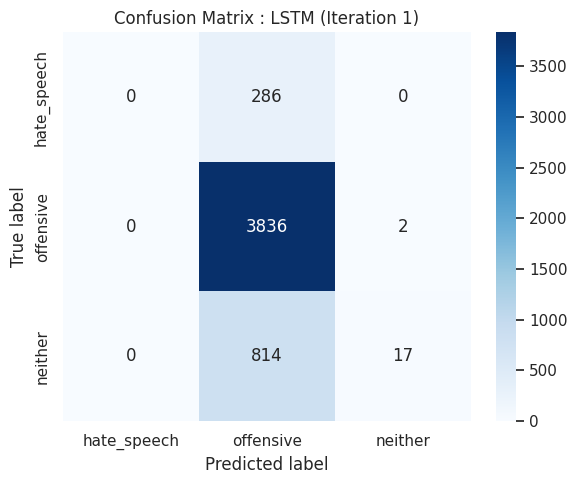

In [58]:
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm_lstm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LABEL_NAMES.values(),
    yticklabels=LABEL_NAMES.values(),
    ax=ax
)

ax.set_title('Confusion Matrix : LSTM (Iteration 1)', fontsize=12)
ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')

plt.tight_layout()
plt.show()